In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
#from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Load the dataset
df = pd.read_csv('deg.csv')

# Check for missing values and handle them
print("Missing values per column:")
print(df.isnull().sum())
df = df.dropna() # Or use df.fillna() with appropriate strategy

Missing values per column:
Ensemble_id                     0
TCGA.KK.A7AU.01A.11R.A32O.07    0
TCGA.VN.A88M.01A.11R.A352.07    0
TCGA.KC.A4BR.01A.32R.A32Y.07    0
TCGA.KC.A7FA.01A.21R.A33R.07    0
                               ..
TCGA.HC.A9TH.01A.11R.A41O.07    0
TCGA.KK.A5A1.01A.11R.A29R.07    0
TCGA.VP.A87J.01A.11R.A352.07    0
TCGA.M7.A720.01A.12R.A32O.07    0
DEG_type                        0
Length: 555, dtype: int64


In [ ]:
print("\nClass distribution:")
print(df['DEG_type'].value_counts())
print(f"Class proportions:\n{df['DEG_type'].value_counts(normalize=True)}")


Class distribution:
DEG_type
Non Significant    22489
Down Regulated      1276
Up Regulated         941
Name: count, dtype: int64
Class proportions:
DEG_type
Non Significant    0.910265
Down Regulated     0.051647
Up Regulated       0.038088
Name: proportion, dtype: float64


In [ ]:
df.shape

(24706, 555)

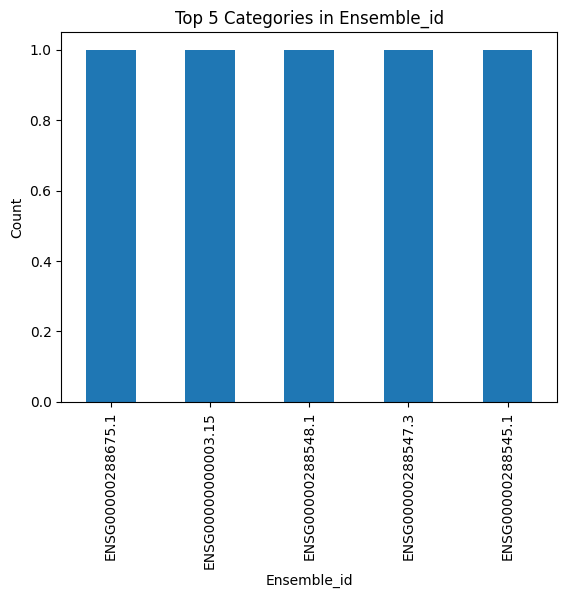

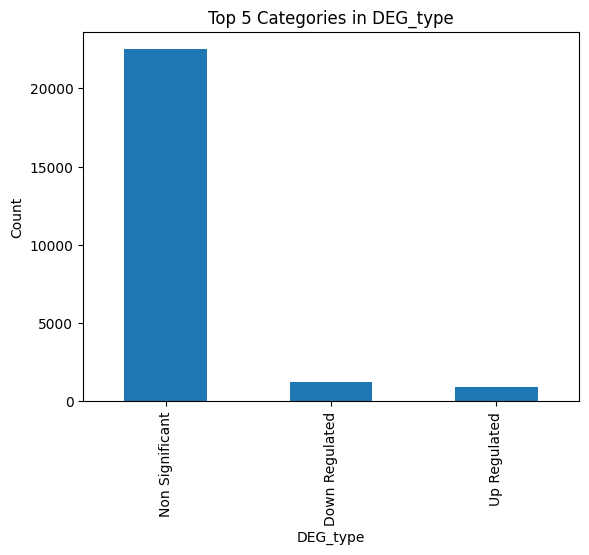

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
cat_cols = df.select_dtypes(include=['object']).columns[:3]

for col in cat_cols:
    df[col].value_counts().head(5).plot(kind='bar')
    plt.title(f"Top 5 Categories in {col}")
    plt.ylabel("Count")
    plt.show()


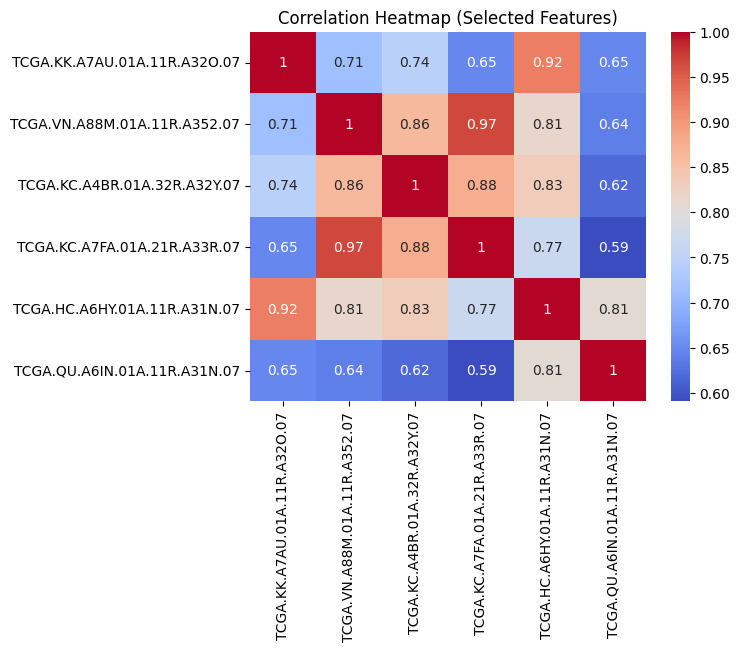

In [ ]:
top_num_cols = df.select_dtypes(include=['int64', 'float64']).columns[:6]

sns.heatmap(df[top_num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Selected Features)")
plt.show()


In [ ]:
X=df.drop(['Ensemble_id','DEG_type'],axis=1)
y=df['DEG_type']

In [ ]:
from imblearn.over_sampling import SMOTE
# Check if classes are imbalanced (if minority class < 30% of majority)
class_counts = y.value_counts()
if class_counts.min() / class_counts.max() < 0.3:
    print("\nClass imbalance detected. Applying SMOTE...")
    smote = SMOTE(random_state=42)
    X, y = smote.fit_resample(X, y)
    print(f"After SMOTE - Class distribution:\n{pd.Series(y).value_counts()}")


Class imbalance detected. Applying SMOTE...
After SMOTE - Class distribution:
DEG_type
Non Significant    22489
Down Regulated     22489
Up Regulated       22489
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=0.95)
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)

In [ ]:
X_train_pca.shape

(53973, 16)

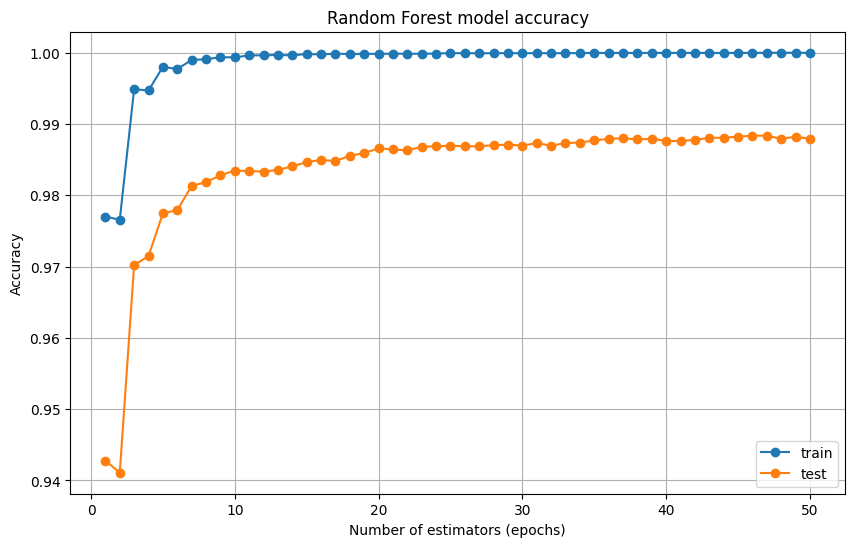

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Assuming X is your feature dataset and y is the target variable
# X, y = ...

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize lists to store accuracy values
train_accuracies = []
test_accuracies = []
epochs = range(1, 51) # 50 epochs

# Train Random Forest model iteratively and track accuracy
for n_estimators in epochs:
    # Initialize and train Random Forest classifier
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    rf.fit(X_train, y_train)

    # Predict on train and test sets
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Append accuracies to lists
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Plotting the accuracies
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracies, label='train', marker='o')
plt.plot(epochs, test_accuracies, label='test', marker='o')
plt.title('Random Forest model accuracy')
plt.xlabel('Number of estimators (epochs)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
models={'rf':RandomForestClassifier(random_state=42),'lr':LogisticRegression(max_iter=1000),'sv':SVC(random_state=42),'kn':KNeighborsClassifier()}

Model: rf
Train Accuracy: 1.0000
Test Accuracy: 0.9880
Classification Report:
                 precision    recall  f1-score   support

 Down Regulated       0.98      1.00      0.99      4498
Non Significant       1.00      0.96      0.98      4498
   Up Regulated       0.99      1.00      0.99      4498

       accuracy                           0.99     13494
      macro avg       0.99      0.99      0.99     13494
   weighted avg       0.99      0.99      0.99     13494



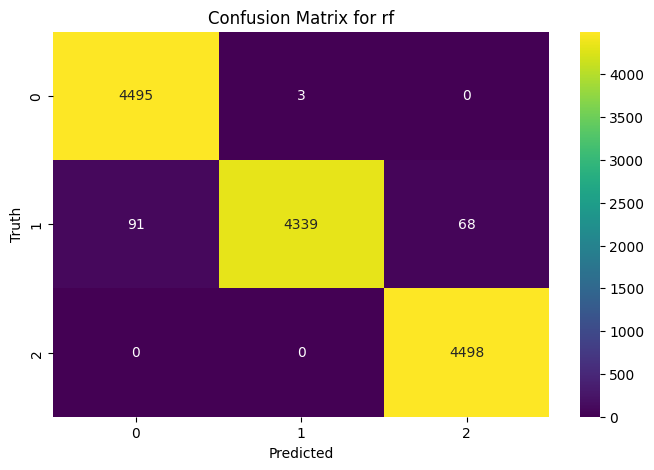

Confusion Matrix:
[[4495    3    0]
 [  91 4339   68]
 [   0    0 4498]]

Model: lr
Train Accuracy: 0.9257
Test Accuracy: 0.9244
Classification Report:
                 precision    recall  f1-score   support

 Down Regulated       0.97      0.99      0.98      4498
Non Significant       0.98      0.79      0.87      4498
   Up Regulated       0.84      1.00      0.91      4498

       accuracy                           0.92     13494
      macro avg       0.93      0.92      0.92     13494
   weighted avg       0.93      0.92      0.92     13494



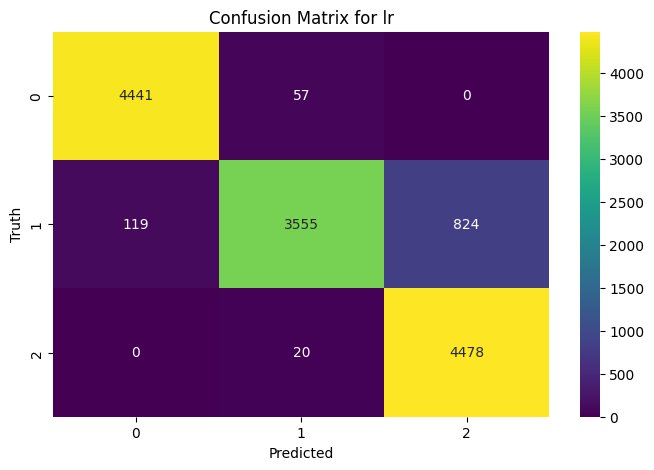

Confusion Matrix:
[[4441   57    0]
 [ 119 3555  824]
 [   0   20 4478]]

Model: sv
Train Accuracy: 0.7071
Test Accuracy: 0.7076
Classification Report:
                 precision    recall  f1-score   support

 Down Regulated       0.95      0.71      0.82      4498
Non Significant       0.99      0.41      0.58      4498
   Up Regulated       0.54      1.00      0.70      4498

       accuracy                           0.71     13494
      macro avg       0.83      0.71      0.70     13494
   weighted avg       0.83      0.71      0.70     13494



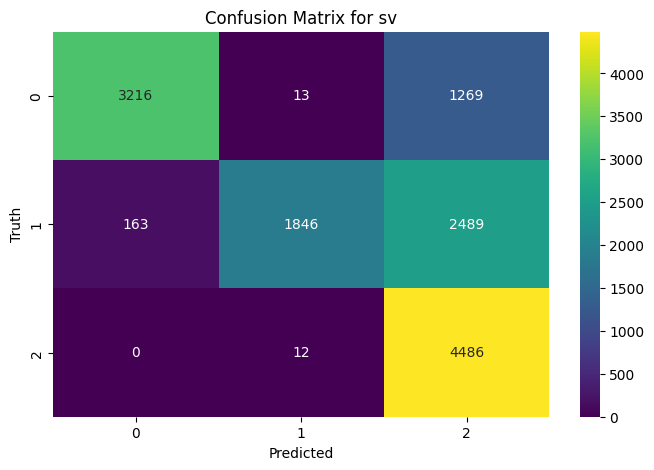

Confusion Matrix:
[[3216   13 1269]
 [ 163 1846 2489]
 [   0   12 4486]]

Model: kn
Train Accuracy: 0.9664
Test Accuracy: 0.9619
Classification Report:
                 precision    recall  f1-score   support

 Down Regulated       0.95      1.00      0.97      4498
Non Significant       1.00      0.89      0.94      4498
   Up Regulated       0.94      1.00      0.97      4498

       accuracy                           0.96     13494
      macro avg       0.96      0.96      0.96     13494
   weighted avg       0.96      0.96      0.96     13494



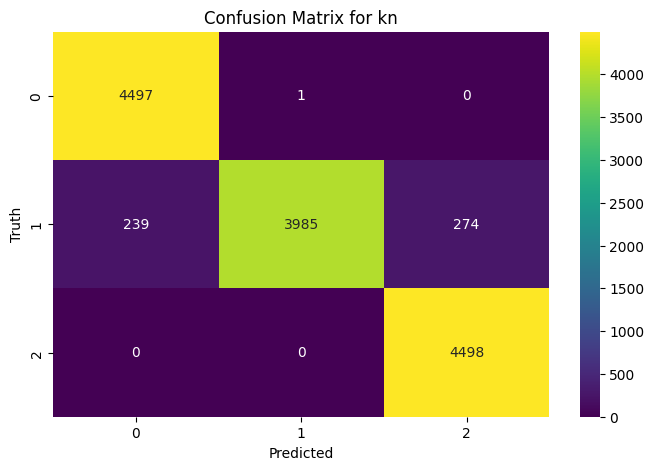

Confusion Matrix:
[[4497    1    0]
 [ 239 3985  274]
 [   0    0 4498]]



In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    print(f"Model: {name}")
    print(f"Train Accuracy: {accuracy_score(y_train,y_train_pred):.4f}")
    print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred))

    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.xlabel('Predicted')
    plt.ylabel('Truth')
    plt.title(f"Confusion Matrix for {name}")
    plt.show()
    print("Confusion Matrix:")
    print(cm)
    print()

In [ ]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(RandomForestClassifier(n_estimators=100,random_state=42),X_train_pca,y_train,cv=5)
print('Cross Validation scores:',scores)
print(scores.mean())

Cross Validation scores: [0.96785549 0.97211672 0.971283   0.97174356 0.97415231]
0.9714302157641145


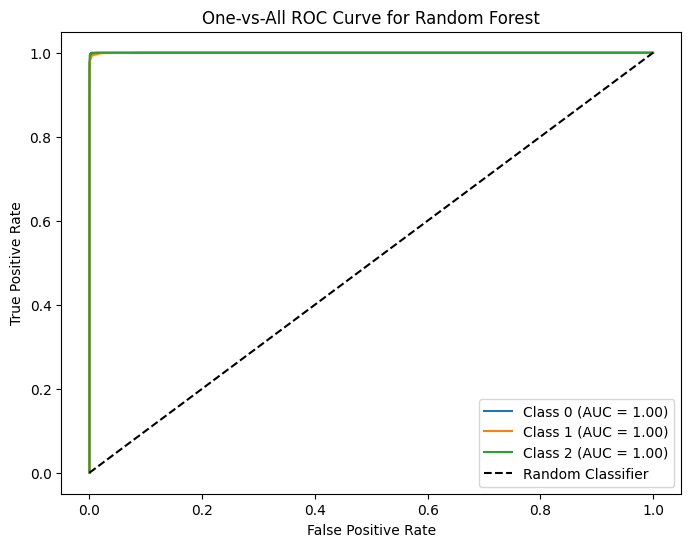

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_test and y_train are your original labels
n_classes = len(np.unique(y_test)) # Number of unique classes

# Binarize the output labels for OvA
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

# Train a random forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Get predicted probabilities
y_pred_proba = rf_model.predict_proba(X_test_scaled)

# Plot ROC curves for each class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc_score:.2f})')

# Plot the baseline (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-All ROC Curve for Random Forest')
plt.legend()
plt.show()


In [6]:
import matplotlib . pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn . decomposition import PCA
from sklearn . preprocessing import MaxAbsScaler,StandardScaler

In [7]:
df=pd.read_csv("deg.csv",index_col=False)

In [8]:
df

,Ensemble_id,TCGA.KK.A7AU.01A.11R.A32O.07,TCGA.VN.A88M.01A.11R.A352.07,TCGA.KC.A4BR.01A.32R.A32Y.07,TCGA.KC.A7FA.01A.21R.A33R.07,TCGA.HC.A6HY.01A.11R.A31N.07,TCGA.QU.A6IN.01A.11R.A31N.07,TCGA.KK.A6E0.01A.11R.A311.07,TCGA.XK.AAJA.01A.11R.A41O.07,TCGA.EJ.5504.01A.01R.1580.07,...,TCGA.YL.A8HK.01A.11R.A36G.07,TCGA.XJ.A9DI.01A.11R.A37L.07,TCGA.VP.A87K.01A.11R.A352.07,TCGA.J4.A67O.01A.11R.A30B.07,TCGA.4L.AA1F.01A.11R.A41O.07,TCGA.HC.A9TH.01A.11R.A41O.07,TCGA.KK.A5A1.01A.11R.A29R.07,TCGA.VP.A87J.01A.11R.A352.07,TCGA.M7.A720.01A.12R.A32O.07,DEG_type
0,ENSG00000000003.15,3459,2874,1789,2458,4490,2418,2838,6559,4599,...,3890.0,2338.0,3617.0,2140.0,2834.0,3904.0,3478.0,1663.0,4452.0,Non Significant
1,ENSG00000000005.6,0,8,116,92,23,3,1,8,3,...,6.0,2.0,2.0,56.0,3.0,1.0,6.0,2.0,134.0,Non Significant
2,ENSG00000000419.13,1612,1090,1330,1286,1500,720,1495,1539,1205,...,1613.0,1301.0,1477.0,844.0,1560.0,2301.0,1356.0,1529.0,1526.0,Non Significant
3,ENSG00000000457.14,1143,687,700,628,741,655,455,1119,873,...,1327.0,811.0,1204.0,193.0,825.0,1276.0,755.0,665.0,989.0,Non Significant
4,ENSG00000000460.17,201,79,159,130,152,80,98,273,165,...,283.0,161.0,155.0,35.0,188.0,263.0,265.0,186.0,209.0,Non Significant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2096,ENSG00000100060.18,117,128,298,228,168,122,269,471,320,...,492.0,602.0,204.0,253.0,865.0,384.0,246.0,152.0,288.0,Non Significant
2097,ENSG00000100065.15,1379,817,1003,645,1387,458,1925,2403,835,...,2001.0,1289.0,1095.0,502.0,899.0,1269.0,786.0,795.0,1269.0,Non Significant
2098,ENSG00000100068.13,305,344,398,344,247,410,111,1446,116,...,578.0,475.0,408.0,88.0,145.0,263.0,106.0,125.0,402.0,Non Significant
2099,ENSG00000100075.10,10989,7536,6108,9521,8201,13360,11191,12453,5573,...,5029.0,3930.0,7324.0,9276.0,4669.0,10851.0,5900.0,8686.0,7801.0,Non Significant


In [9]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# 3. Fit and transform the 'Color' column
# This assigns a unique integer to each category (e.g., Blue=0, Green=1, Red=2 based on alphabetical order).
df['DEG_type'] = label_encoder.fit_transform(df['DEG_type'])

In [10]:
print(label_encoder.classes_)

['Down Regulated' 'Non Significant' 'Up Regulated' nan]


In [11]:
import imblearn
X=df.iloc[:,1:554]
y=df.iloc[:,-1]

In [12]:
X.head()

,TCGA.KK.A7AU.01A.11R.A32O.07,TCGA.VN.A88M.01A.11R.A352.07,TCGA.KC.A4BR.01A.32R.A32Y.07,TCGA.KC.A7FA.01A.21R.A33R.07,TCGA.HC.A6HY.01A.11R.A31N.07,TCGA.QU.A6IN.01A.11R.A31N.07,TCGA.KK.A6E0.01A.11R.A311.07,TCGA.XK.AAJA.01A.11R.A41O.07,TCGA.EJ.5504.01A.01R.1580.07,TCGA.M7.A723.01A.12R.A32O.07,...,TCGA.EJ.7789.11A.01R.2118.07,TCGA.YL.A8HK.01A.11R.A36G.07,TCGA.XJ.A9DI.01A.11R.A37L.07,TCGA.VP.A87K.01A.11R.A352.07,TCGA.J4.A67O.01A.11R.A30B.07,TCGA.4L.AA1F.01A.11R.A41O.07,TCGA.HC.A9TH.01A.11R.A41O.07,TCGA.KK.A5A1.01A.11R.A29R.07,TCGA.VP.A87J.01A.11R.A352.07,TCGA.M7.A720.01A.12R.A32O.07
0,3459,2874,1789,2458,4490,2418,2838,6559,4599,3160,...,8080.0,3890.0,2338.0,3617.0,2140.0,2834.0,3904.0,3478.0,1663.0,4452.0
1,0,8,116,92,23,3,1,8,3,3,...,30.0,6.0,2.0,2.0,56.0,3.0,1.0,6.0,2.0,134.0
2,1612,1090,1330,1286,1500,720,1495,1539,1205,1370,...,2193.0,1613.0,1301.0,1477.0,844.0,1560.0,2301.0,1356.0,1529.0,1526.0
3,1143,687,700,628,741,655,455,1119,873,319,...,1471.0,1327.0,811.0,1204.0,193.0,825.0,1276.0,755.0,665.0,989.0
4,201,79,159,130,152,80,98,273,165,87,...,236.0,283.0,161.0,155.0,35.0,188.0,263.0,265.0,186.0,209.0


In [13]:
y.unique()

array([1, 0, 2, 3])

In [14]:
scaler = StandardScaler()
#scaler = MaxAbsScaler()
X_scale= scaler.fit_transform(X)

In [15]:
from sklearn.impute import SimpleImputer

# Impute missing values before PCA
imputer = SimpleImputer(strategy='mean')
X_scale_imputed = imputer.fit_transform(X_scale)

pca = PCA()
projected = pca.fit_transform(X_scale_imputed) # Use the imputed data
print(projected.shape)

(2101, 553)


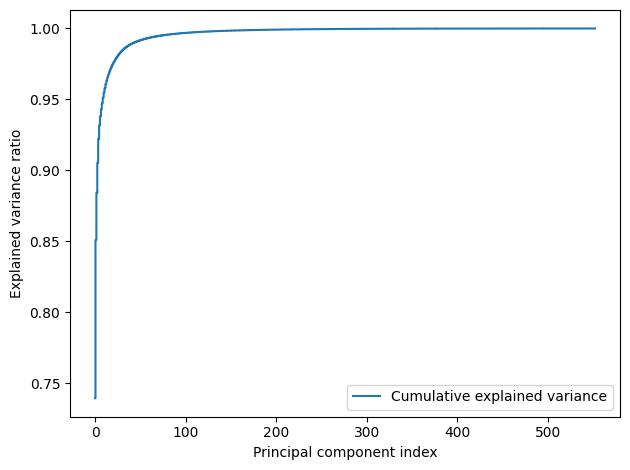

In [16]:
# Determine explained variance using explained_variance_ration_ attribute
#
exp_var_pca = pca.explained_variance_ratio_
#
# Cumulative sum of eigenvalues; This will be used to create step plot
# for visualizing the variance explained by each principal component.
#
cum_sum_eigenvalues = np.cumsum(exp_var_pca)
#
# Create the visualization plot
#
#plt.bar(range(0,len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(0,len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid',label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Second Principal Component')

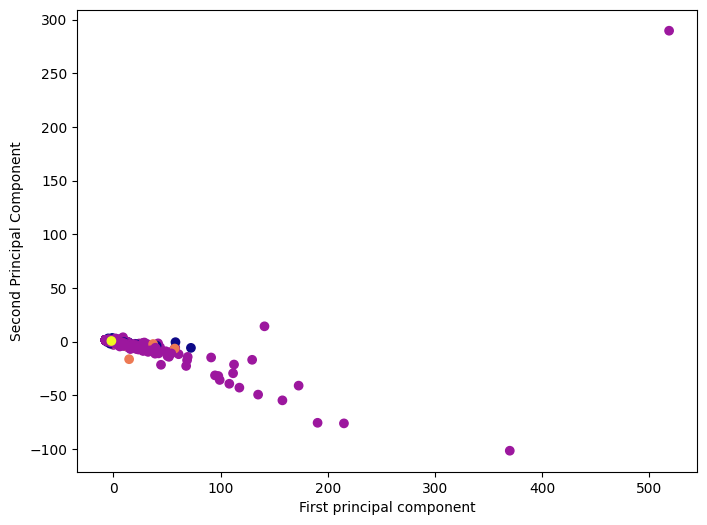

In [17]:
pca = PCA(n_components=80)
X_trans = pca.fit_transform(X_scale_imputed)

plt.figure(figsize=(8,6))
plt.scatter(X_trans[:,0],X_trans[:,1],c=y,cmap='plasma')
plt.xlabel('First principal component')
plt.ylabel('Second Principal Component')

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier,OneVsOneClassifier

In [19]:
from mlxtend.classifier import StackingCVClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import model_selection

In [20]:
# transform the dataset
from imblearn.over_sampling import SMOTE

# Filter out rows where y is the 'nan' class (label 3)
# Assuming 3 is the label assigned to NaN by LabelEncoder
valid_indices = y != 3
X_trans_filtered = X_trans[valid_indices]
y_filtered = y[valid_indices]

oversample = SMOTE()
X1, y1 = oversample.fit_resample(X_trans_filtered, y_filtered)

In [21]:
from sklearn.preprocessing import label_binarize
# Binarize the output
y1 = label_binarize(y1, classes=[0, 1, 2])
n_classes = y1.shape[1]

In [22]:
# shuffle and split training and test sets
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc,RocCurveDisplay
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.20, random_state=20)

In [23]:
#FOr KNN only (Finding K value)
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': range(5, 15),
              'weights': ['uniform', 'distance'],
              'metric': ['euclidean', 'manhattan']}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5,
                           scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_:.4f}")

KeyboardInterrupt: 

In [24]:
RANDOM_SEED = 42

clf1 = KNeighborsClassifier(metric='euclidean', n_neighbors=6, weights='distance')
clf2 = RandomForestClassifier(random_state=RANDOM_SEED,max_features= 'log2', n_estimators=50)
clf3 = MLPClassifier(activation = "relu", alpha = 0.1, hidden_layer_sizes = (10,10,10),
                            learning_rate = "constant", max_iter = 2000, random_state = 1000)
clf6 = XGBClassifier(learning_rate=0.2, max_depth=9, n_estimators=50,subsample=0.5)
clf4 = SVC(C= 1.0, gamma= 1, kernel='rbf',probability = True)
clf5 = GradientBoostingClassifier(learning_rate= 0.1, max_depth=9, n_estimators=100, subsample= 0.5)
lr = LogisticRegression(solver='lbfgs', max_iter=1000)

In [ ]:
X1.shape

(24525, 80)

In [ ]:
# Learn to predict each class against the other
classifier = OneVsRestClassifier(clf2)

In [ ]:
y_test.shape

(4905, 3)

In [ ]:
y1.shape

(24525, 3)

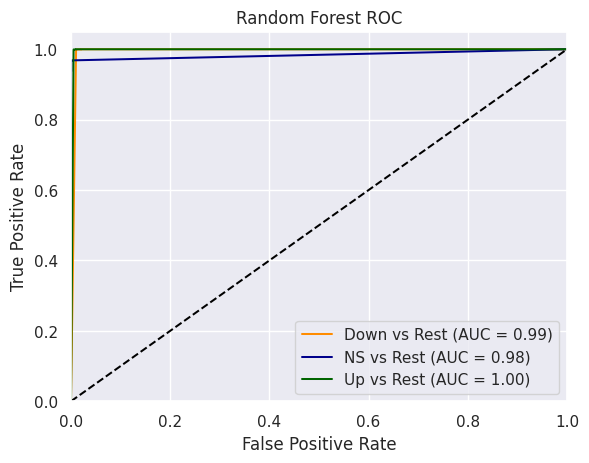

In [ ]:
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 1.45
plt.plot(fpr[0], tpr[0], color='darkorange',
         lw=lw, label='Down vs Rest (AUC = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkblue',
         lw=lw, label='NS vs Rest (AUC = %0.2f)' % roc_auc[1])
plt.plot(fpr[2], tpr[2], color='darkgreen',
         lw=lw, label='Up vs Rest (AUC = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC')
plt.legend(loc="lower right")
plt.show()

In [28]:
from sklearn.metrics import classification_report,confusion_matrix,matthews_corrcoef

In [ ]:
target_names = ['Down', 'NS', 'UP']
y_pred = classifier.predict(X_test)
y_pred1=np.argmax(y_pred, axis=1)
y_test1=np.argmax(y_test, axis=1)
print(classification_report(y_test1, y_pred1, target_names=target_names))

              precision    recall  f1-score   support

        Down       0.94      1.00      0.97      1658
          NS       1.00      0.93      0.96      1620
          UP       0.99      1.00      0.99      1627

    accuracy                           0.98      4905
   macro avg       0.98      0.98      0.98      4905
weighted avg       0.98      0.98      0.98      4905



In [ ]:
matthews_corrcoef(y_test1, y_pred1,sample_weight=None)

np.float64(0.9660944374811627)

In [ ]:
import pickle
# create an iterator object with write permission - model.pkl
with open('SCV_pkl', 'wb') as files:
    pickle.dump(classifier, files)

In [ ]:
import joblib
# saving our model # model - model , filename-model_jlib
joblib.dump(classifier , 'SCV_jlib')

['SCV_jlib']

In [ ]:
cf_matrix = confusion_matrix(y_test1,y_pred1)

Text(0.5, 1.0, 'RF confusion matrix')

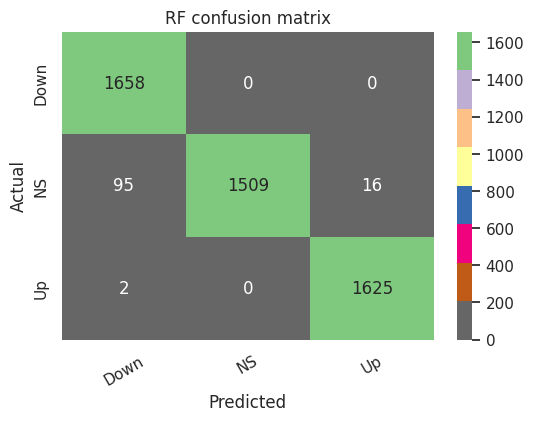

In [ ]:
df_cm = pd.DataFrame(cf_matrix, columns=np.unique(y_test1), index = np.unique(y_test1))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
class_labels=['Down','NS','Up']
tick_marks=np.arange(len(class_labels))+0.5
plt.figure(figsize = (6,4))
sns.set(font_scale=1)#for label size
axes=sns.heatmap(df_cm, cmap=plt.cm.Accent_r, annot=True,annot_kws={"size": 12},fmt='.0f')# font size
axes.set_xticks(tick_marks)
axes.set_xticklabels(class_labels,rotation=30)

axes.set_yticks(tick_marks)
axes.set_yticklabels(class_labels,rotation=90)
axes.set_title("RF confusion matrix")

In [ ]:
classifier = OneVsRestClassifier(clf1)

In [ ]:
y_test.shape

(4905, 3)

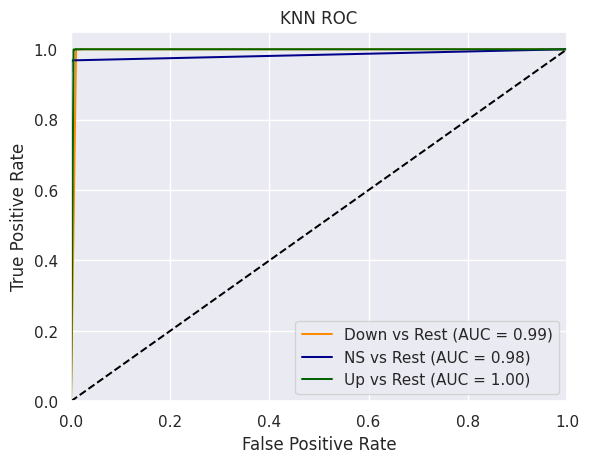

In [ ]:
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 1.45
plt.plot(fpr[0], tpr[0], color='darkorange',
         lw=lw, label='Down vs Rest (AUC = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkblue',
         lw=lw, label='NS vs Rest (AUC = %0.2f)' % roc_auc[1])
plt.plot(fpr[2], tpr[2], color='darkgreen',
         lw=lw, label='Up vs Rest (AUC = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC')
plt.legend(loc="lower right")
plt.show()


In [ ]:
target_names = ['Down', 'NS', 'UP']
y_pred = classifier.predict(X_test)
y_pred1=np.argmax(y_pred, axis=1)
y_test1=np.argmax(y_test, axis=1)
print(classification_report(y_test1, y_pred1, target_names=target_names))

              precision    recall  f1-score   support

        Down       0.94      1.00      0.97      1658
          NS       1.00      0.90      0.95      1620
          UP       0.97      1.00      0.98      1627

    accuracy                           0.97      4905
   macro avg       0.97      0.97      0.97      4905
weighted avg       0.97      0.97      0.97      4905



In [ ]:
matthews_corrcoef(y_test1, y_pred1,sample_weight=None)

np.float64(0.9536801298372402)

In [ ]:
cf_matrix = confusion_matrix(y_test1,y_pred1)

Text(0.5, 1.0, 'KNN confusion matrix')

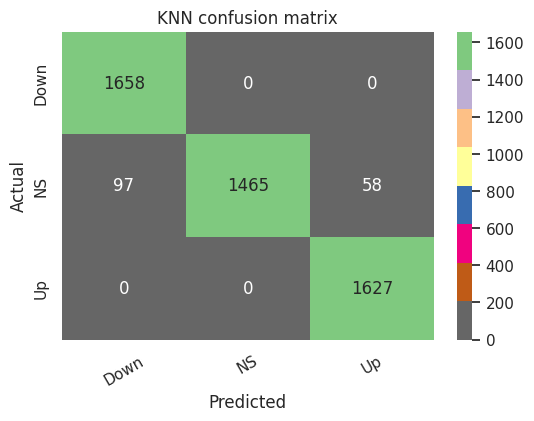

In [ ]:
df_cm = pd.DataFrame(cf_matrix, columns=np.unique(y_test1), index = np.unique(y_test1))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
class_labels=['Down','NS','Up']
tick_marks=np.arange(len(class_labels))+0.5
plt.figure(figsize = (6,4))
sns.set(font_scale=1)#for label size
axes=sns.heatmap(df_cm, cmap=plt.cm.Accent_r, annot=True,annot_kws={"size": 12},fmt='.0f')# font size
axes.set_xticks(tick_marks)
axes.set_xticklabels(class_labels,rotation=30)

axes.set_yticks(tick_marks)
axes.set_yticklabels(class_labels,rotation=90)
axes.set_title("KNN confusion matrix")

In [ ]:
classifier = OneVsRestClassifier(clf3)

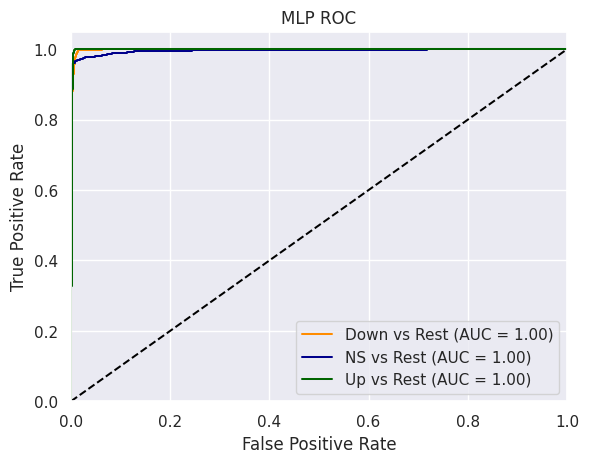

In [ ]:
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 1.45
plt.plot(fpr[0], tpr[0], color='darkorange',
         lw=lw, label='Down vs Rest (AUC = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkblue',
         lw=lw, label='NS vs Rest (AUC = %0.2f)' % roc_auc[1])
plt.plot(fpr[2], tpr[2], color='darkgreen',
         lw=lw, label='Up vs Rest (AUC = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MLP ROC')
plt.legend(loc="lower right")
plt.show()

In [ ]:
target_names = ['Down', 'NS', 'UP']
y_pred = classifier.predict(X_test)
y_pred1=np.argmax(y_pred, axis=1)
y_test1=np.argmax(y_test, axis=1)
print(classification_report(y_test1, y_pred1, target_names=target_names))

              precision    recall  f1-score   support

        Down       0.96      1.00      0.98      1658
          NS       1.00      0.95      0.97      1620
          UP       0.99      1.00      0.99      1627

    accuracy                           0.98      4905
   macro avg       0.98      0.98      0.98      4905
weighted avg       0.98      0.98      0.98      4905



In [ ]:
matthews_corrcoef(y_test1, y_pred1,sample_weight=None)

np.float64(0.9724801751662677)

In [ ]:
cf_matrix = confusion_matrix(y_test1,y_pred1)

Text(0.5, 1.0, 'MLP confusion matrix')

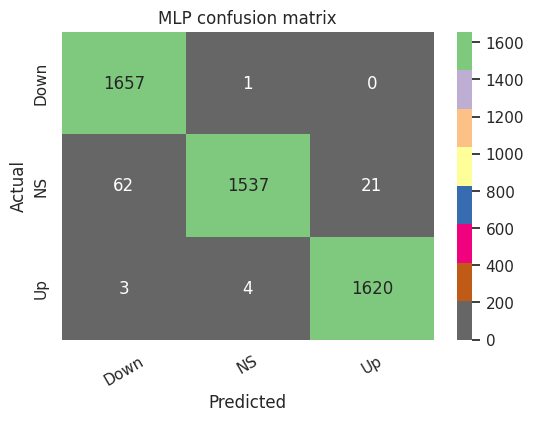

In [ ]:
df_cm = pd.DataFrame(cf_matrix, columns=np.unique(y_test1), index = np.unique(y_test1))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
class_labels=['Down','NS','Up']
tick_marks=np.arange(len(class_labels))+0.5
plt.figure(figsize = (6,4))
sns.set(font_scale=1)#for label size
axes=sns.heatmap(df_cm, cmap=plt.cm.Accent_r, annot=True,annot_kws={"size": 12},fmt='.0f')# font size
axes.set_xticks(tick_marks)
axes.set_xticklabels(class_labels,rotation=30)

axes.set_yticks(tick_marks)
axes.set_yticklabels(class_labels,rotation=90)
axes.set_title("MLP confusion matrix")

In [ ]:
classifier = OneVsRestClassifier(clf5)

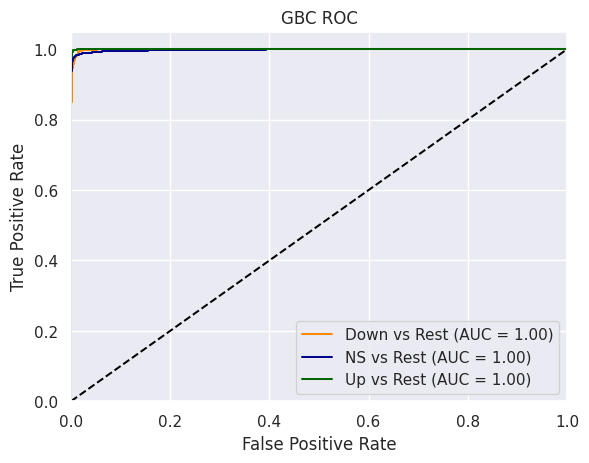

In [ ]:
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 1.45
plt.plot(fpr[0], tpr[0], color='darkorange',
         lw=lw, label='Down vs Rest (AUC = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkblue',
         lw=lw, label='NS vs Rest (AUC = %0.2f)' % roc_auc[1])
plt.plot(fpr[2], tpr[2], color='darkgreen',
         lw=lw, label='Up vs Rest (AUC = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GBC ROC')
plt.legend(loc="lower right")
plt.show()

In [ ]:
target_names = ['Down', 'NS', 'UP']
y_pred = classifier.predict(X_test)
y_pred1=np.argmax(y_pred, axis=1)
y_test1=np.argmax(y_test, axis=1)
print(classification_report(y_test1, y_pred1, target_names=target_names))

              precision    recall  f1-score   support

        Down       0.96      1.00      0.98      1658
          NS       1.00      0.94      0.97      1620
          UP       0.98      1.00      0.99      1627

    accuracy                           0.98      4905
   macro avg       0.98      0.98      0.98      4905
weighted avg       0.98      0.98      0.98      4905



In [ ]:
matthews_corrcoef(y_test1, y_pred1,sample_weight=None)

np.float64(0.9677505938785315)

In [ ]:
cf_matrix = confusion_matrix(y_test1,y_pred1)

Text(0.5, 1.0, 'GBC confusion matrix')

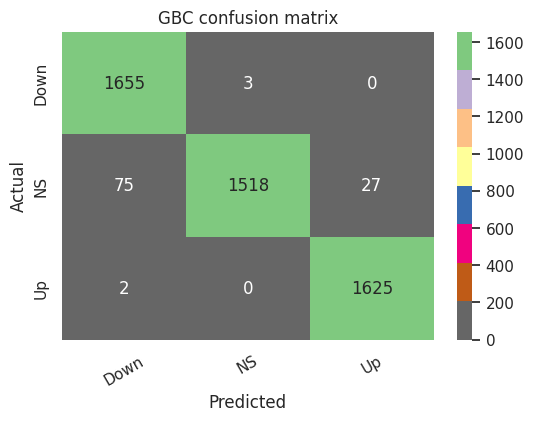

In [ ]:
df_cm = pd.DataFrame(cf_matrix, columns=np.unique(y_test1), index = np.unique(y_test1))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
class_labels=['Down','NS','Up']
tick_marks=np.arange(len(class_labels))+0.5
plt.figure(figsize = (6,4))
sns.set(font_scale=1)#for label size
axes=sns.heatmap(df_cm, cmap=plt.cm.Accent_r, annot=True,annot_kws={"size": 12},fmt='.0f')# font size
axes.set_xticks(tick_marks)
axes.set_xticklabels(class_labels,rotation=30)

axes.set_yticks(tick_marks)
axes.set_yticklabels(class_labels,rotation=90)
axes.set_title("GBC confusion matrix")

In [ ]:
classifier = OneVsRestClassifier(clf6)

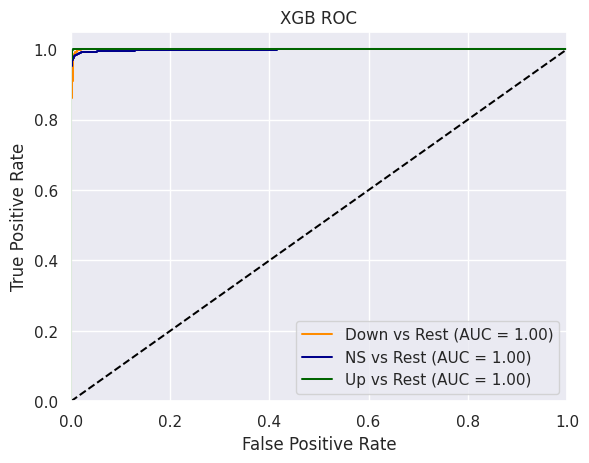

In [ ]:
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 1.45
plt.plot(fpr[0], tpr[0], color='darkorange',
         lw=lw, label='Down vs Rest (AUC = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkblue',
         lw=lw, label='NS vs Rest (AUC = %0.2f)' % roc_auc[1])
plt.plot(fpr[2], tpr[2], color='darkgreen',
         lw=lw, label='Up vs Rest (AUC = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGB ROC')
plt.legend(loc="lower right")
plt.show()

In [ ]:
target_names = ['Down', 'NS', 'UP']
y_pred = classifier.predict(X_test)
y_pred1=np.argmax(y_pred, axis=1)
y_test1=np.argmax(y_test, axis=1)
print(classification_report(y_test1, y_pred1, target_names=target_names))

              precision    recall  f1-score   support

        Down       0.96      1.00      0.98      1658
          NS       1.00      0.94      0.97      1620
          UP       0.99      1.00      0.99      1627

    accuracy                           0.98      4905
   macro avg       0.98      0.98      0.98      4905
weighted avg       0.98      0.98      0.98      4905



In [ ]:
matthews_corrcoef(y_test1, y_pred1,sample_weight=None)

np.float64(0.9713971697477806)

In [ ]:
cf_matrix = confusion_matrix(y_test1,y_pred1)

Text(0.5, 1.0, 'XGB confusion matrix')

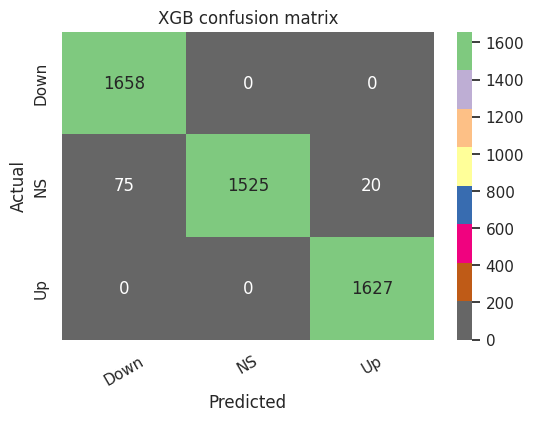

In [ ]:
df_cm = pd.DataFrame(cf_matrix, columns=np.unique(y_test1), index = np.unique(y_test1))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
class_labels=['Down','NS','Up']
tick_marks=np.arange(len(class_labels))+0.5
plt.figure(figsize = (6,4))
sns.set(font_scale=1)#for label size
axes=sns.heatmap(df_cm, cmap=plt.cm.Accent_r, annot=True,annot_kws={"size": 12},fmt='.0f')# font size
axes.set_xticks(tick_marks)
axes.set_xticklabels(class_labels,rotation=30)

axes.set_yticks(tick_marks)
axes.set_yticklabels(class_labels,rotation=90)
axes.set_title("XGB confusion matrix")

In [ ]:
classifier = OneVsRestClassifier(clf4)

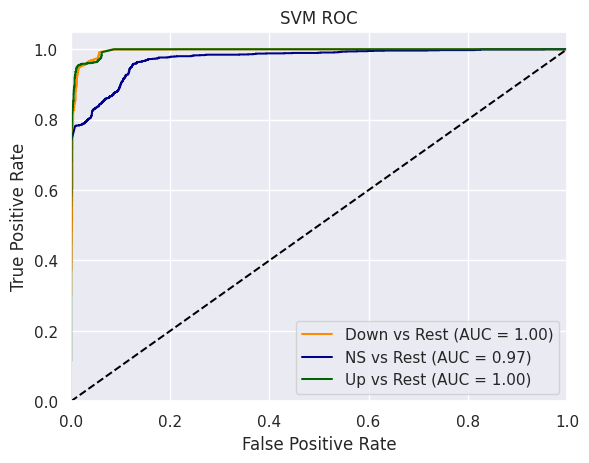

In [ ]:
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 1.45
plt.plot(fpr[0], tpr[0], color='darkorange',
         lw=lw, label='Down vs Rest (AUC = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkblue',
         lw=lw, label='NS vs Rest (AUC = %0.2f)' % roc_auc[1])
plt.plot(fpr[2], tpr[2], color='darkgreen',
         lw=lw, label='Up vs Rest (AUC = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC')
plt.legend(loc="lower right")
plt.show()

In [ ]:
target_names = ['Down', 'NS', 'UP']
y_pred = classifier.predict(X_test)
y_pred1=np.argmax(y_pred, axis=1)
y_test1=np.argmax(y_test, axis=1)
print(classification_report(y_test1, y_pred1, target_names=target_names))

              precision    recall  f1-score   support

        Down       0.85      0.96      0.90      1658
          NS       0.90      0.81      0.86      1620
          UP       0.97      0.95      0.96      1627

    accuracy                           0.91      4905
   macro avg       0.91      0.91      0.91      4905
weighted avg       0.91      0.91      0.91      4905



In [ ]:
matthews_corrcoef(y_test1, y_pred1,sample_weight=None)

np.float64(0.8615395048404951)

In [ ]:
cf_matrix = confusion_matrix(y_test1,y_pred1)

Text(0.5, 1.0, 'SVM confusion matrix')

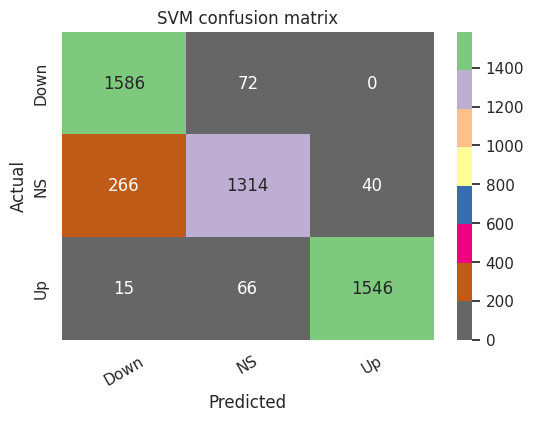

In [ ]:
df_cm = pd.DataFrame(cf_matrix, columns=np.unique(y_test1), index = np.unique(y_test1))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
class_labels=['Down','NS','Up']
tick_marks=np.arange(len(class_labels))+0.5
plt.figure(figsize = (6,4))
sns.set(font_scale=1)#for label size
axes=sns.heatmap(df_cm, cmap=plt.cm.Accent_r, annot=True,annot_kws={"size": 12},fmt='.0f')# font size
axes.set_xticks(tick_marks)
axes.set_xticklabels(class_labels,rotation=30)

axes.set_yticks(tick_marks)
axes.set_yticklabels(class_labels,rotation=90)
axes.set_title("SVM confusion matrix")

In [25]:
# Learn to predict each class against the other
classifier = OneVsRestClassifier(lr)

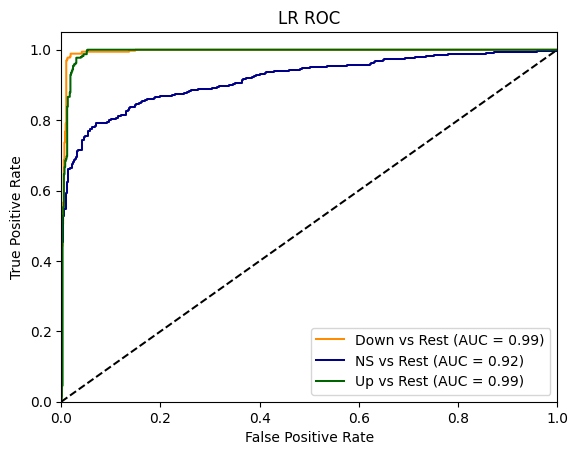

In [26]:
y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
lw = 1.45
plt.plot(fpr[0], tpr[0], color='darkorange',
         lw=lw, label='Down vs Rest (AUC = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkblue',
         lw=lw, label='NS vs Rest (AUC = %0.2f)' % roc_auc[1])
plt.plot(fpr[2], tpr[2], color='darkgreen',
         lw=lw, label='Up vs Rest (AUC = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LR ROC')
plt.legend(loc="lower right")
plt.show()

In [30]:
target_names = ['Down', 'NS', 'UP']
y_pred = classifier.predict(X_test)
y_pred1=np.argmax(y_pred, axis=1)
y_test1=np.argmax(y_test, axis=1)
print(classification_report(y_test1, y_pred1, target_names=target_names))

              precision    recall  f1-score   support

        Down       0.77      0.99      0.87       357
          NS       0.99      0.66      0.79       402
          UP       0.92      0.99      0.96       396

    accuracy                           0.88      1155
   macro avg       0.89      0.88      0.87      1155
weighted avg       0.90      0.88      0.87      1155



In [31]:
matthews_corrcoef(y_test1, y_pred1,sample_weight=None)

np.float64(0.8312665908230565)

In [32]:
cf_matrix = confusion_matrix(y_test1,y_pred1)

Text(0.5, 1.0, 'LR confusion matrix')

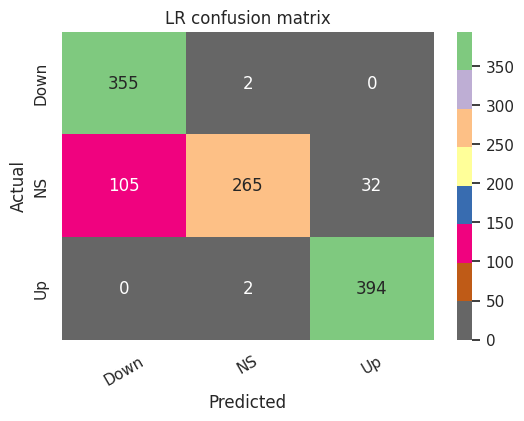

In [33]:
df_cm = pd.DataFrame(cf_matrix, columns=np.unique(y_test1), index = np.unique(y_test1))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
class_labels=['Down','NS','Up']
tick_marks=np.arange(len(class_labels))+0.5
plt.figure(figsize = (6,4))
sns.set(font_scale=1)#for label size
axes=sns.heatmap(df_cm, cmap=plt.cm.Accent_r, annot=True,annot_kws={"size": 12},fmt='.0f')# font size
axes.set_xticks(tick_marks)
axes.set_xticklabels(class_labels,rotation=30)

axes.set_yticks(tick_marks)
axes.set_yticklabels(class_labels,rotation=90)
axes.set_title("LR confusion matrix")